Using device: cpu

Dataset Information:
Original dataset shape: (2520751, 53)

Available columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd

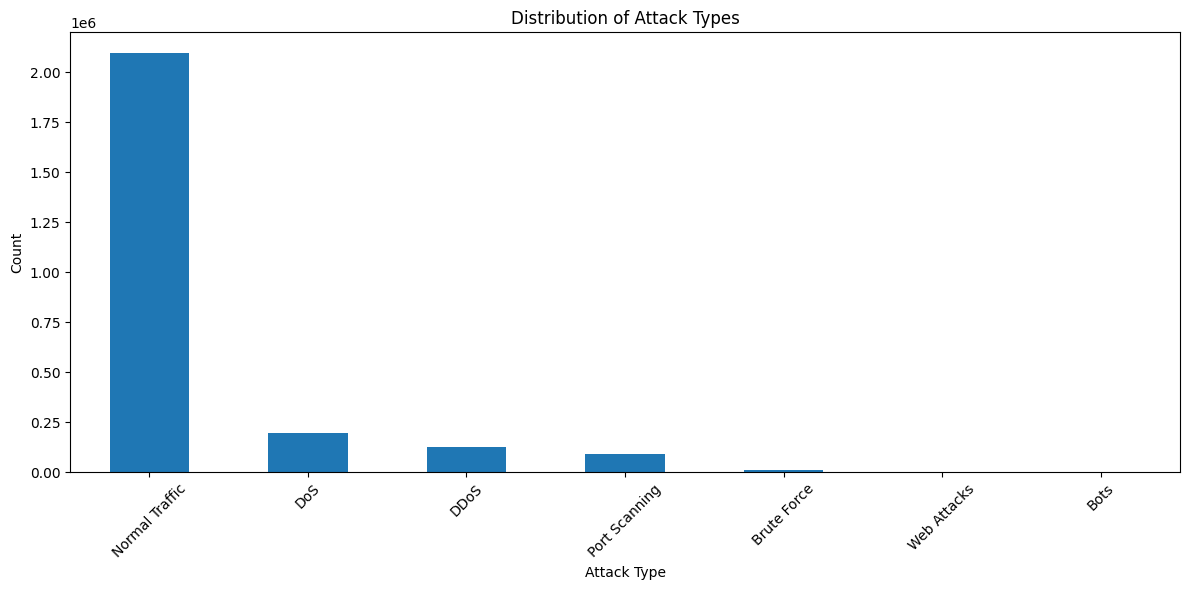


Number of features selected: 52

Selected features:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Length of Fwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'Average Packet Size', 'Subflow Fwd Bytes', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Ac

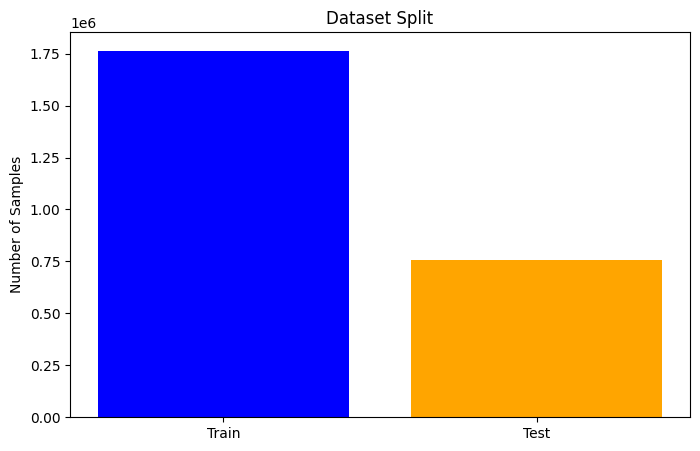


Model architecture:
EnhancedNet(
  (fc1): Linear(in_features=52, out_features=256, bias=True)
  (bn1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=2, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)
Iteration 0, Meta Loss: 0.7067
Iteration 1, Meta Loss: 0.7113
Iteration 2, Meta Loss: 0.7036
Iteration 3, Meta Loss: 0.7136
Iteration 4, Meta Loss: 0.7103
Iteration 5, Meta Loss: 0.6990
Iteration 6, Meta Loss: 0.7113
Iteration 7, Meta Loss: 0.7103
Iteration 8, Meta Loss: 0.7153
Iteration 9, Meta Loss: 0.7127


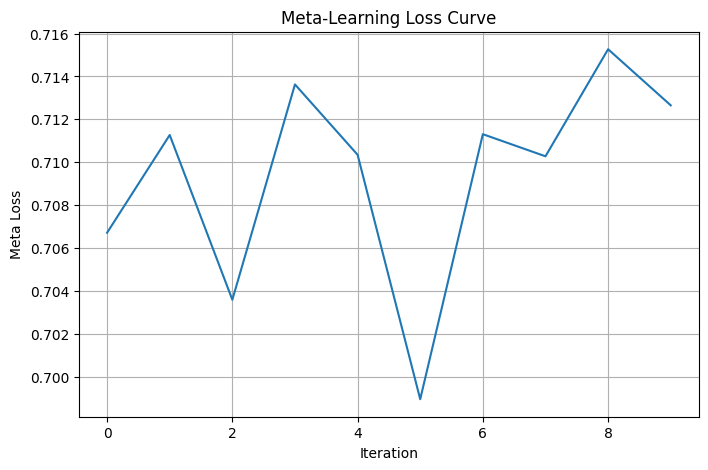


Evaluation on Test Set:

Performance Metrics:
Accuracy: 0.969808
Precision: 0.999210
Recall: 0.970552
F1-Score: 0.984673
False Positive Rate (FPR): 0.993151
False Negative Rate (FNR): 0.029448
Detection Rate: 0.970552

Confusion Matrix:
True Positives (TP): 733390
True Negatives (TN): 4
False Positives (FP): 580
False Negatives (FN): 22252


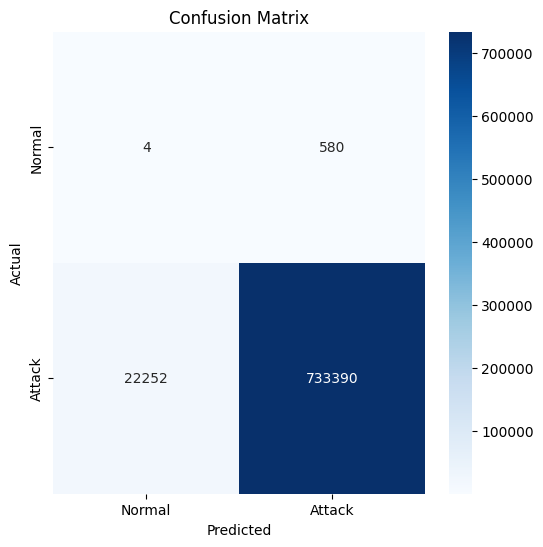


Classification Report:
              precision    recall  f1-score   support

      Normal       0.00      0.01      0.00       584
      Attack       1.00      0.97      0.98    755642

    accuracy                           0.97    756226
   macro avg       0.50      0.49      0.49    756226
weighted avg       1.00      0.97      0.98    756226

Model saved as 'final_model.pth'


In [6]:
# Add reproducibility measures at the very top
import random
import numpy as np
import torch

# Set all random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Rest of the code
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Check for CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Step 1 - Load and Preprocess the Dataset
path = r"C:\Users\chari\Downloads\cicids2017_cleaned.csv"
df = pd.read_csv(path)

# Dataset Information
print("\nDataset Information:")
print(f"Original dataset shape: {df.shape}")
print("\nAvailable columns:", df.columns.tolist())
print("\nAttack Type distribution:")
print(df['Attack Type'].value_counts())

# Visualize Attack Type distribution
plt.figure(figsize=(12, 6))
df['Attack Type'].value_counts().plot(kind='bar')
plt.title('Distribution of Attack Types')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('attack_distribution.png', bbox_inches='tight')
plt.show()

# Handle infinities and NaNs
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# Encode labels
label_encoder = LabelEncoder()
df['Attack Type'] = label_encoder.fit_transform(df['Attack Type'])

# Feature selection (using all features for MAML demonstration)
selected_features = [col for col in df.columns if col != 'Attack Type']
print(f"\nNumber of features selected: {len(selected_features)}")
print("\nSelected features:")
print(selected_features)

X = df[selected_features]
y = df['Attack Type']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test with fixed random state
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=seed, stratify=y
)

# Convert to torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

# Dataset shapes visualization
plt.figure(figsize=(8, 5))
plt.bar(['Train', 'Test'], [len(X_train), len(X_test)], color=['blue', 'orange'])
plt.title('Dataset Split')
plt.ylabel('Number of Samples')
plt.savefig('dataset_split.png', bbox_inches='tight')
plt.show()

# Step 2 - Create reproducible tasks for MAML
def create_task(X, y, k_support=20, k_query=20):
    # Create a generator with fixed seed
    generator = torch.Generator(device=device).manual_seed(seed)
    
    # For binary classification (normal vs attack)
    y_binary = (y != 0).long()
    
    indices_0 = (y_binary == 0).nonzero(as_tuple=True)[0]
    indices_1 = (y_binary == 1).nonzero(as_tuple=True)[0]

    # Sample with reproducible randomness
    s0 = torch.randperm(len(indices_0), generator=generator)[:k_support + k_query]
    s1 = torch.randperm(len(indices_1), generator=generator)[:k_support + k_query]

    support_idx = torch.cat([indices_0[s0[:k_support]], indices_1[s1[:k_support]]])
    query_idx = torch.cat([indices_0[s0[k_support:]], indices_1[s1[k_support:]]])

    return X[support_idx], y_binary[support_idx], X[query_idx], y_binary[query_idx]

# Step 3 - Define Enhanced Model
class EnhancedNet(nn.Module):
    def __init__(self, input_dim):  # <-- fixed here
        super(EnhancedNet, self).__init__()  # <-- fixed here
        self.fc1 = nn.Linear(input_dim, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 2)  # Binary classification
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        return self.fc4(x)


# Clone utility
def clone_model(model):
    cloned = EnhancedNet(model.fc1.in_features).to(device)
    cloned.load_state_dict(model.state_dict())
    return cloned

# Step 4 - Improved MAML Training with Reproducibility
def maml_train(model, X, y, k_support=20, k_query=20, inner_lr=0.01, 
               meta_lr=0.001, num_tasks=10, iterations=10):
    # Pre-generate all tasks for reproducibility
    tasks = []
    generator = torch.Generator(device=device).manual_seed(seed)
    for _ in range(iterations * num_tasks):
        # For reproducibility, create each task with fixed randomness
        y_binary = (y != 0).long()
        indices_0 = (y_binary == 0).nonzero(as_tuple=True)[0]
        indices_1 = (y_binary == 1).nonzero(as_tuple=True)[0]
        
        s0 = torch.randperm(len(indices_0), generator=generator)[:k_support + k_query]
        s1 = torch.randperm(len(indices_1), generator=generator)[:k_support + k_query]
        
        support_idx = torch.cat([indices_0[s0[:k_support]], indices_1[s1[:k_support]]])
        query_idx = torch.cat([indices_0[s0[k_support:]], indices_1[s1[k_support:]]])
        
        tasks.append((
            X[support_idx], 
            y_binary[support_idx],
            X[query_idx], 
            y_binary[query_idx]
        ))
    
    meta_optimizer = optim.Adam(model.parameters(), lr=meta_lr, weight_decay=1e-4)
    losses = []
    best_loss = float('inf')
    best_model_state = None

    for iteration in range(iterations):
        meta_optimizer.zero_grad()
        meta_loss = 0

        for task_idx in range(num_tasks):
            support_x, support_y, query_x, query_y = tasks[iteration * num_tasks + task_idx]
            support_x, support_y = support_x.to(device), support_y.to(device)
            query_x, query_y = query_x.to(device), query_y.to(device)

            # Clone model for inner loop
            temp_model = clone_model(model)
            inner_optimizer = optim.SGD(temp_model.parameters(), lr=inner_lr)
            
            # Inner loop (adaptation)
            inner_optimizer.zero_grad()
            loss = F.cross_entropy(temp_model(support_x), support_y)
            loss.backward()
            inner_optimizer.step()

            # Meta-loss (evaluation on query set)
            query_preds = temp_model(query_x)
            task_loss = F.cross_entropy(query_preds, query_y)
            task_loss.backward()
            meta_loss += task_loss.item()

        # Clip gradients to prevent explosion
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        meta_optimizer.step()
        avg_meta_loss = meta_loss / num_tasks
        losses.append(avg_meta_loss)

        # Save best model
        if avg_meta_loss < best_loss:
            best_loss = avg_meta_loss
            best_model_state = model.state_dict().copy()
            torch.save(best_model_state, 'best_model.pth')

        #if iteration % 10 == 0:
        print(f"Iteration {iteration}, Meta Loss: {avg_meta_loss:.4f}")

    # Load best model state
    model.load_state_dict(best_model_state)
    
    # Plot training loss
    plt.figure(figsize=(8, 5))
    plt.plot(losses)
    plt.title('Meta-Learning Loss Curve')
    plt.xlabel('Iteration')
    plt.ylabel('Meta Loss')
    plt.grid(True)
    plt.savefig('training_loss.png', bbox_inches='tight')
    plt.show()
    
    return model

# Step 5 - Train
input_dim = X_train_tensor.shape[1]
model = EnhancedNet(input_dim).to(device)
print("\nModel architecture:")
print(model)

model = maml_train(model, X_train_tensor, y_train_tensor, iterations=10)

# Step 6 - Enhanced Evaluation
def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        # Convert to binary for evaluation
        y_test_binary = (y_test != 0).long().cpu().numpy()
        
        # Get predictions
        outputs = model(X_test)
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
        preds = preds.cpu().numpy()
        
        # Calculate metrics
        accuracy = accuracy_score(y_test_binary, preds)
        precision = precision_score(y_test_binary, preds, zero_division=0)
        recall = recall_score(y_test_binary, preds, zero_division=0)
        f1 = f1_score(y_test_binary, preds, zero_division=0)
        
        # Confusion matrix
        cm = confusion_matrix(y_test_binary, preds)
        if cm.size == 1:  # Handle case with only one class
            if y_test_binary[0] == 0:
                tn, fp, fn, tp = cm[0,0], 0, 0, 0
            else:
                tn, fp, fn, tp = 0, 0, 0, cm[0,0]
        else:
            tn, fp, fn, tp = cm.ravel()
        
        # Additional metrics
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        detection_rate = tp / (tp + fn) if (tp + fn) > 0 else 0
        
        print("\nPerformance Metrics:")
        print(f"Accuracy: {accuracy:.6f}")
        print(f"Precision: {precision:.6f}")
        print(f"Recall: {recall:.6f}")
        print(f"F1-Score: {f1:.6f}")
        print(f"False Positive Rate (FPR): {fpr:.6f}")
        print(f"False Negative Rate (FNR): {fnr:.6f}")
        print(f"Detection Rate: {detection_rate:.6f}")
        
        print("\nConfusion Matrix:")
        print(f"True Positives (TP): {tp}")
        print(f"True Negatives (TN): {tn}")
        print(f"False Positives (FP): {fp}")
        print(f"False Negatives (FN): {fn}")
        
        # Plot confusion matrix
        plt.figure(figsize=(6, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=['Normal', 'Attack'], 
                    yticklabels=['Normal', 'Attack'])
        plt.title('Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.savefig('confusion_matrix.png', bbox_inches='tight')
        plt.show()
        
        # Classification report
        print("\nClassification Report:")
        print(classification_report(y_test_binary, preds, target_names=['Normal', 'Attack'], zero_division=0))
        
        # Save metrics to file
        with open('metrics_report.txt', 'w') as f:
            f.write(f"Accuracy: {accuracy:.6f}\n")
            f.write(f"Precision: {precision:.6f}\n")
            f.write(f"Recall: {recall:.6f}\n")
            f.write(f"F1-Score: {f1:.6f}\n\n")
            f.write(f"FPR: {fpr:.6f}\n")
            f.write(f"FNR: {fnr:.6f}\n")
            f.write(f"Detection Rate: {detection_rate:.6f}\n")
            f.write("\nConfusion Matrix:\n")
            f.write(f"TP: {tp}, TN: {tn}, FP: {fp}, FN: {fn}\n")
            f.write("\nClassification Report:\n")
            f.write(classification_report(y_test_binary, preds, target_names=['Normal', 'Attack'], zero_division=0))

# Evaluate on test set
print("\nEvaluation on Test Set:")
evaluate_model(model, X_test_tensor, y_test_tensor)

# Save the final model
torch.save(model.state_dict(), 'final_model.pth')
print("Model saved as 'final_model.pth'")